# Malli 3: Hienosäädetty VGG16

Tässä notebookissa vapautetaan viimeiset VGG16:n kerrokset ja hienosäädetään malli omalla datalla.

**Huom:** Notebook näyttää tulokset vasta sen jälkeen, kun solut on suoritettu. Aja solut järjestyksessä tai valitse `Run All`.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path('..').resolve()))
sys.path.append(str(Path('..', 'src').resolve()))

from data_pipeline import create_generators
from models import build_fine_tuned_model
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = '../dataset/structured'
BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)
EPOCHS = 10
UNFROZEN_LAYERS = 4

train_gen, val_gen, test_gen = create_generators(DATA_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
NUM_CLASSES = len(train_gen.class_indices)
INPUT_SHAPE = (*IMAGE_SIZE, 3)

Found 149 images belonging to 2 classes.


Found 31 images belonging to 2 classes.


Found 34 images belonging to 2 classes.


In [3]:
model = build_fine_tuned_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, unfrozen_layers=UNFROZEN_LAYERS)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 13,502,722 (51.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [4]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1,
)

Epoch 1/10


 1/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8000 - loss: 0.4930

 2/10 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8286 - loss: 0.8313 

 3/10 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7506 - loss: 1.6611

 4/10 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7186 - loss: 1.9047

...

 7/10 ━━━━━━━━━━━━━━━━━━━━ 2s 947ms/step - accuracy: 0.7219 - loss: 0.6212

 8/10 ━━━━━━━━━━━━━━━━━━━━ 1s 964ms/step - accuracy: 0.7224 - loss: 0.6207

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 979ms/step - accuracy: 0.7215 - loss: 0.6209

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 981ms/step - accuracy: 0.7219 - loss: 0.6206

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7248 - loss: 0.6173 - val_accuracy: 0.7419 - val_loss: 0.6045


In [5]:
test_loss, test_acc = model.evaluate(test_gen)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.3750 - loss: 0.7837

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.5312 - loss: 0.7074

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.5895 - loss: 0.6790

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.7059 - loss: 0.6221


Test loss: 0.6221
Test accuracy: 0.7059


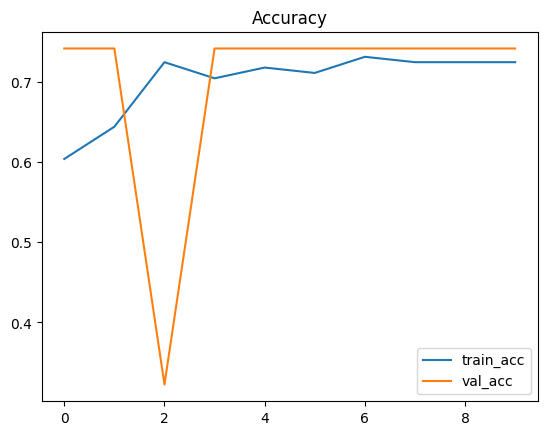

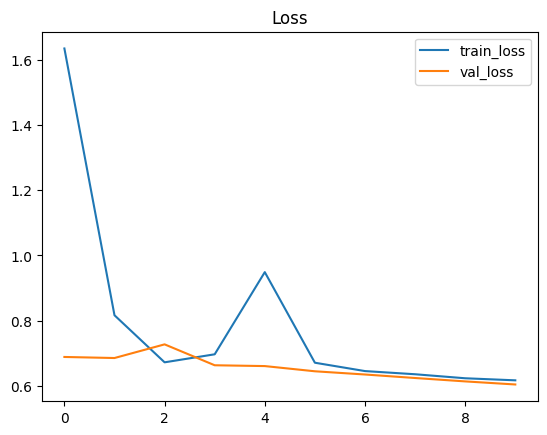

In [6]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.show()